In [1]:
# Core imports
import pandas as pd
import numpy as np
import time
import random
import pyautogui
import re
from datetime import datetime, timedelta

# Selenium imports
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import (
    TimeoutException, 
    NoSuchElementException,
    StaleElementReferenceException
)

# For automatic chromedriver management
from webdriver_manager.chrome import ChromeDriverManager

# For parsing HTML
from bs4 import BeautifulSoup

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


The first step is to do the scrapping

In [ ]:
# FERHO AMB CLASSIFICATION NO AMB DICTIONARIES?
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor

# Les pagines que vull van de la 63 a la 13012 (haure de treure algun del 2026 i del 2000 potser)
# 1 = [63,1050] (23 mins)
# 2 = [1051, 2100] (45 mins)
# 3 = [2101, 4100] (73 mins)
# 4 = [4101, 6000] (77 mins)
# 5 = [6001, 8000]
# 6 = [8001, 10000]
# 7 = [10001, 11000]
# 8 = [11001, 13015]

PAGE_START = 4101 
PAGE_END = 6000    

def get_obituaries_from_page(page_num):
    base_url = "https://www.currentobituary.com"
    url = f"{base_url}/browse/p/{page_num}"
    try:
        r = requests.get(url, timeout=15)
        if r.status_code != 200: return []
        
        soup = BeautifulSoup(r.text, 'html.parser')
        items = []
        
        for el in soup.select(".username"):
            span = el.select_one("span")
            link = el.select_one("a")
            
            if span and link:
                date_txt = span.get_text().strip()
                href = link['href']
                
                # CORRECCIÓ: Si la URL és relativa, hi afegim la base
                full_url = href if href.startswith("http") else base_url + href
                
               
                items.append({
                    "url": full_url,
                    "data": date_txt
                })
        return items
    except:
        return []

def get_biografia_fast(url):
    try:
        r = requests.get(url, timeout=10)
        soup = BeautifulSoup(r.text, 'html.parser')
        container = soup.find(id="tab-obituary")
        if container:
            paragraphs = container.find_all("p")
            if paragraphs:
                txt = max([p.get_text().strip() for p in paragraphs], key=len)
                return txt if len(txt) > 50 else "Text massa curt"
        return "Text no trobat"
    except:
        return "Error"   

def fetch_full_data(item):
    item['biografia'] = get_biografia_fast(item['url'])
    return item

# --- EXECUCIÓ ---

if __name__ == "__main__":
    all_links = []
        
    # PAS 1: Recollir URLs (sense Selenium, només Requests = velocitat màxima)
    for p in range(PAGE_START, PAGE_END + 1):
        found = get_obituaries_from_page(p)
        if found:
            all_links.extend(found)
            # Si trobem dades, anem imprimint per saber on som
            print(f"    📄 Pàgina {p}: Trobats {len(found)} casos. (Total acumulat: {len(all_links)})")
        
        if p % 10 == 0: time.sleep(1) # Pausa per no ser bloquejats

    # PAS 2: Scraping de biografies
    if not all_links:
        print("❌ No s'ha trobat res. Prova d'ajustar PAGE_START.")
    else:
        print(f"\n📂 Iniciant scraping de {len(all_links)} biografies...")
        final_results = []
        
        # Usem ThreadPool per anar ràpid
        with ThreadPoolExecutor(max_workers=10) as executor:
            final_results = list(executor.map(fetch_full_data, all_links))
        
        # Guardat final
        df = pd.DataFrame(final_results)
        df.to_csv("obituaris_4_FINAL.csv", index=False, encoding='utf-8-sig')
        print("✅ FET! Arxiu 'obituaris_4_FINAL.csv' generat.")

🚀 Cercant obituaris del 2015 entre pàgines 5285 i 5987...
    📄 Pàgina 5285: Trobats 13 casos de 2015. (Total acumulat: 13)
    📄 Pàgina 5286: Trobats 20 casos de 2015. (Total acumulat: 33)
    📄 Pàgina 5287: Trobats 20 casos de 2015. (Total acumulat: 53)
    📄 Pàgina 5288: Trobats 20 casos de 2015. (Total acumulat: 73)
    📄 Pàgina 5289: Trobats 20 casos de 2015. (Total acumulat: 93)
    📄 Pàgina 5290: Trobats 20 casos de 2015. (Total acumulat: 113)
    📄 Pàgina 5291: Trobats 20 casos de 2015. (Total acumulat: 133)
    📄 Pàgina 5292: Trobats 20 casos de 2015. (Total acumulat: 153)
    📄 Pàgina 5293: Trobats 20 casos de 2015. (Total acumulat: 173)
    📄 Pàgina 5294: Trobats 20 casos de 2015. (Total acumulat: 193)
    📄 Pàgina 5295: Trobats 20 casos de 2015. (Total acumulat: 213)
    📄 Pàgina 5296: Trobats 20 casos de 2015. (Total acumulat: 233)
    📄 Pàgina 5297: Trobats 20 casos de 2015. (Total acumulat: 253)
    📄 Pàgina 5298: Trobats 20 casos de 2015. (Total acumulat: 273)
    📄 Pàg

--- RELIGIOUS INDEX RESULTS ---
Average Religiosity 2015: 1.45%
Average Religiosity 2025: 1.14%
Change: -21.38%


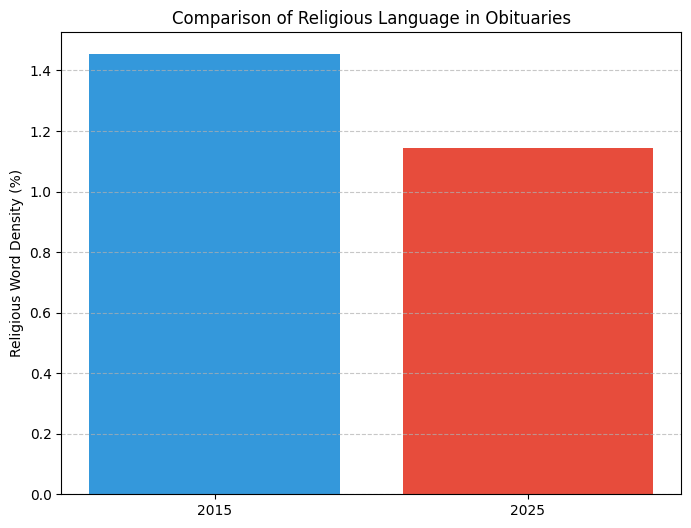

In [16]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. RELIGIOUS DICTIONARY
# Expanded to catch more nuances of religious life
religion_dict = [
    'church', 'faith', 'god', 'jesus', 'christ', 'lord', 'pastor', 'reverend', 
    'priest', 'bible', 'scripture', 'catholic', 'baptist', 'methodist', 
    'christian', 'faithfully', 'heaven', 'blessed', 'prayer', 'pray', 
    'ministry', 'choir', 'spirit', 'spiritual', 'soul', 'devout', 'parish',
    'mass', 'vatican', 'amen', 'worship', 'congregation', 'clerical'
]

def get_religious_index(text):
    text = str(text).lower()
    # Tokenize: find all words
    words = re.findall(r'\b\w{3,}\b', text) # Only words with 3+ letters to avoid noise
    if not words: return 0
    
    # Count occurrences of dictionary words
    # Using 'any' allows catching 'churches' from 'church'
    count = sum(1 for word in words if any(rel_word in word for rel_word in religion_dict))
    
    # Return percentage: (religious_words / total_words) * 100
    return (count / len(words)) * 100

# 2. LOAD AND PROCESS
def analyze_year(file_path):
    df = pd.read_csv(file_path).dropna(subset=['biografia'])
    # Clean technical errors from scraping
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]
    
    df['rel_index'] = df['biografia'].apply(get_religious_index)
    return df['rel_index']

# Run the analysis
rel_2015 = analyze_year("obituaris_2015_FINAL.csv")
rel_2025 = analyze_year("obituaris_2025_FINAL.csv")

# 3. RESULTS
mean_15 = rel_2015.mean()
mean_25 = rel_2025.mean()
diff = ((mean_25 - mean_15) / mean_15) * 100

print(f"--- RELIGIOUS INDEX RESULTS ---")
print(f"Average Religiosity 2015: {mean_15:.2f}%")
print(f"Average Religiosity 2025: {mean_25:.2f}%")
print(f"Change: {diff:.2f}%")

# 4. VISUALIZATION
plt.figure(figsize=(8, 6))
plt.bar(['2015', '2025'], [mean_15, mean_25], color=['#3498db', '#e74c3c'])
plt.ylabel('Religious Word Density (%)')
plt.title('Comparison of Religious Language in Obituaries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- PROFESSIONAL INDEX RESULTS ---
Average Professional Focus 2015: 1.20%
Average Professional Focus 2025: 1.16%
Change in Career Mention: -3.61%


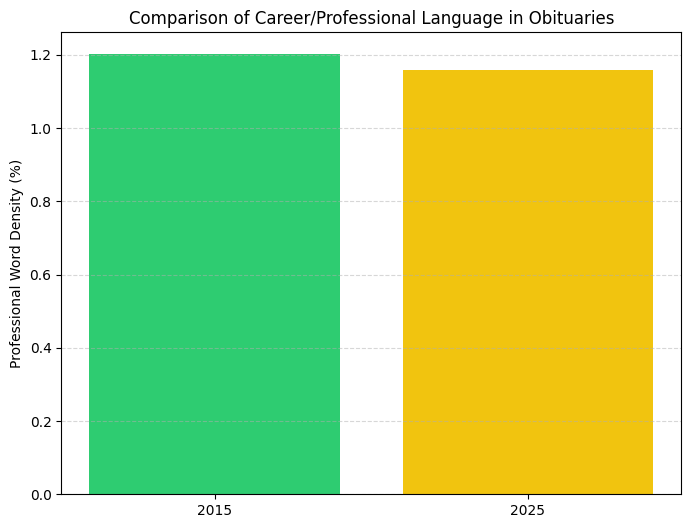

In [17]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. PROFESSIONAL & CAREER DICTIONARY
# We include words related to work, degrees, retirement, and specific roles
professional_dict = [
    'career', 'retired', 'worked', 'employed', 'professor', 'teacher', 
    'engineer', 'manager', 'director', 'business', 'company', 'university', 
    'degree', 'graduated', 'college', 'professional', 'owner', 'founder', 
    'department', 'industry', 'office', 'corporation', 'executive', 'nurse',
    'doctor', 'military', 'veteran', 'served', 'army', 'navy', 'position'
]

def get_professional_index(text):
    text = str(text).lower()
    # Tokenize: 3+ letters to ignore 'he', 'is', 'at'
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Count matches from the dictionary
    count = sum(1 for word in words if any(prof_word in word for prof_word in professional_dict))
    
    # Percentage of the text dedicated to career
    return (count / len(words)) * 100

def analyze_year(file_path):
    df = pd.read_csv(file_path).dropna(subset=['biografia'])
    # Clean technical errors
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]
    
    df['prof_index'] = df['biografia'].apply(get_professional_index)
    return df['prof_index']

# 2. EXECUTION
prof_2015 = analyze_year("obituaris_2015_FINAL.csv")
prof_2025 = analyze_year("obituaris_2025_FINAL.csv")

# 3. STATISTICAL RESULTS
mean_15 = prof_2015.mean()
mean_25 = prof_2025.mean()
diff = ((mean_25 - mean_15) / mean_15) * 100

print(f"--- PROFESSIONAL INDEX RESULTS ---")
print(f"Average Professional Focus 2015: {mean_15:.2f}%")
print(f"Average Professional Focus 2025: {mean_25:.2f}%")
print(f"Change in Career Mention: {diff:.2f}%")

# 4. VISUALIZATION
plt.figure(figsize=(8, 6))
plt.bar(['2015', '2025'], [mean_15, mean_25], color=['#2ecc71', '#f1c40f'])
plt.ylabel('Professional Word Density (%)')
plt.title('Comparison of Career/Professional Language in Obituaries')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

--- FAMILY INDEX RESULTS ---
Average Family Focus 2015: 7.86%
Average Family Focus 2025: 7.13%
Change in Family Mention: -9.28%


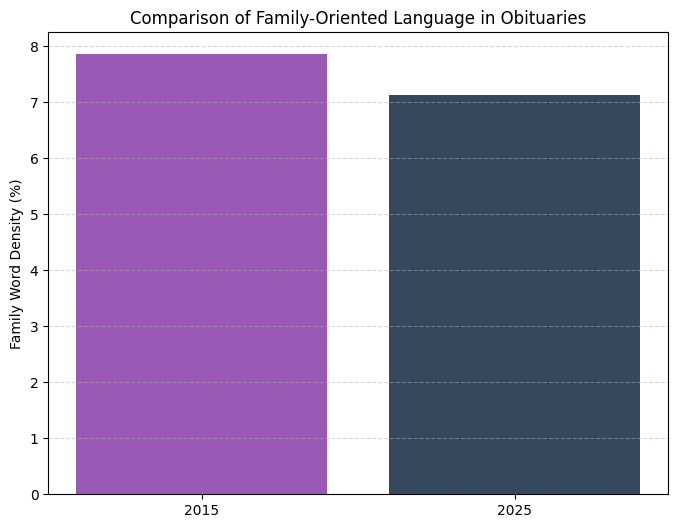

In [18]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. FAMILY & DOMESTIC DICTIONARY
# We include immediate and extended family, plus words of affection
family_dict = [
    'family', 'mother', 'father', 'son', 'daughter', 'brother', 'sister',
    'grandchild', 'grandchildren', 'grandson', 'granddaughter', 'grandmother',
    'grandfather', 'nana', 'papa', 'niece', 'nephew', 'cousin', 'aunt', 'uncle',
    'husband', 'wife', 'spouse', 'partner', 'loving', 'beloved', 'devoted',
    'survived', 'children', 'great-grandchildren', 'parent'
]

def get_family_index(text):
    text = str(text).lower()
    # Tokenize: 3+ letters
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Count matches
    count = sum(1 for word in words if any(fam_word in word for fam_word in family_dict))
    
    # Percentage of the text dedicated to family ties
    return (count / len(words)) * 100

def analyze_year(file_path):
    df = pd.read_csv(file_path).dropna(subset=['biografia'])
    # Clean errors
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]
    
    df['fam_index'] = df['biografia'].apply(get_family_index)
    return df['fam_index']

# 2. RUN ANALYSIS
fam_2015 = analyze_year("obituaris_2015_FINAL.csv")
fam_2025 = analyze_year("obituaris_2025_FINAL.csv")

# 3. STATISTICAL COMPARISON
mean_15 = fam_2015.mean()
mean_25 = fam_2025.mean()
diff = ((mean_25 - mean_15) / mean_15) * 100

print(f"--- FAMILY INDEX RESULTS ---")
print(f"Average Family Focus 2015: {mean_15:.2f}%")
print(f"Average Family Focus 2025: {mean_25:.2f}%")
print(f"Change in Family Mention: {diff:.2f}%")

# 4. VISUALIZATION
plt.figure(figsize=(8, 6))
plt.bar(['2015', '2025'], [mean_15, mean_25], color=['#9b59b6', '#34495e'])
plt.ylabel('Family Word Density (%)')
plt.title('Comparison of Family-Oriented Language in Obituaries')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

--- LIFESTYLE INDEX RESULTS ---
Average Lifestyle Focus 2015: 1.28%
Average Lifestyle Focus 2025: 1.68%
Change in Lifestyle: 31.56%


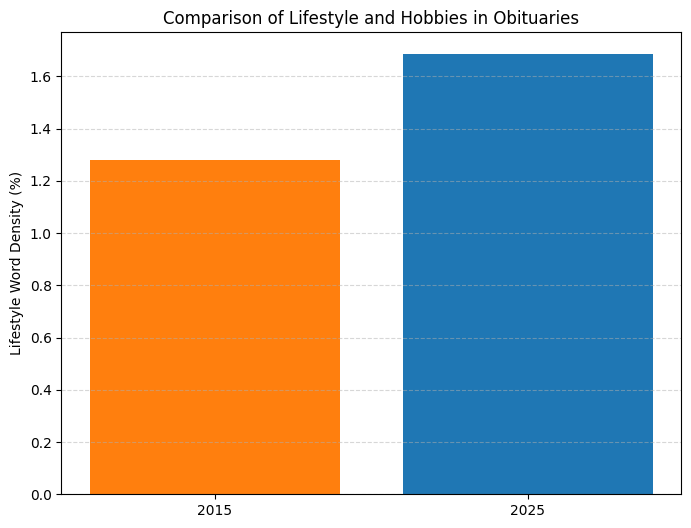

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI D'ESTIL DE VIDA (LIFESTYLE & HOBBIES)
# Incloem viatges, oci, esports, animals i passions personals
lifestyle_dict = [
    'travel', 'traveled', 'journey', 'adventure', 'hiking', 'sailing', 'golf', 
    'gardening', 'cooking', 'music', 'concerts', 'art', 'reading', 'books', 
    'nature', 'outdoors', 'animals', 'dogs', 'cats', 'pets', 'beach', 'lake',
    'traveling', 'passion', 'enjoyed', 'hobbies', 'photography', 'sports', 
    'fan', 'watching', 'food', 'wine', 'restaurant', 'club', 'fishing', 
    'camping', 'collector', 'painting', 'dance', 'dancing', 'volunteering'
]

def get_lifestyle_index(text):
    text = str(text).lower()
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Comptem coincidències amb el diccionari de lifestyle
    count = sum(1 for word in words if any(ls_word in word for ls_word in lifestyle_dict))
    
    # Retornem el percentatge de densitat
    return (count / len(words)) * 100

def analyze_year(file_path):
    df = pd.read_csv(file_path).dropna(subset=['biografia'])
    # Netegem errors de l'scraping
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]
    
    df['ls_index'] = df['biografia'].apply(get_lifestyle_index)
    return df['ls_index']

# 2. EXECUCIÓ DE L'ANÀLISI
ls_2015 = analyze_year("obituaris_2015_FINAL.csv")
ls_2025 = analyze_year("obituaris_2025_FINAL.csv")

# 3. RESULTATS ESTADÍSTICS
mean_15 = ls_2015.mean()
mean_25 = ls_2025.mean()
diff = ((mean_25 - mean_15) / mean_15) * 100

print(f"--- LIFESTYLE INDEX RESULTS ---")
print(f"Average Lifestyle Focus 2015: {mean_15:.2f}%")
print(f"Average Lifestyle Focus 2025: {mean_25:.2f}%")
print(f"Change in Lifestyle: {diff:.2f}%")

# 4. VISUALITZACIÓ
plt.figure(figsize=(8, 6))
plt.bar(['2015', '2025'], [mean_15, mean_25], color=['#ff7f0e', '#1f77b4'])
plt.ylabel('Lifestyle Word Density (%)')
plt.title('Comparison of Lifestyle and Hobbies in Obituaries')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()